/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8199 - loss: 0.4986 - val_accuracy: 0.8368 - val_loss: 0.4392
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8646 - loss: 0.3682 - val_accuracy: 0.8620 - val_loss: 0.3690
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8763 - loss: 0.3321 - val_accuracy: 0.8743 - val_loss: 0.3393
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8870 - loss: 0.3061 - val_accuracy: 0.8675 - val_loss: 0.3453
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8923 - loss: 0.2893 - val_accuracy: 0.8770 - val_loss: 0.3376
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8982 - loss: 0.2732 - val_accuracy: 0.8777 - val_loss: 0.3383
Epoch 7/10
1688/1688 ━━━━━

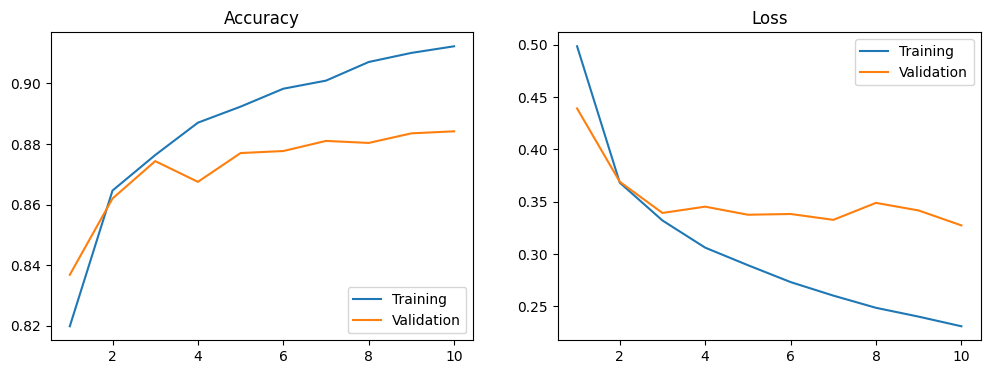

In [3]:
from tensorflow.keras import models, layers
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

model=models.Sequential([layers.Flatten(input_shape=(28,28)),layers.Dense(256,activation='relu'),
                         layers.Dense(128,activation='relu'),layers.Dense(64,activation='relu'),
                         layers.Dense(10,activation='softmax')])
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.summary()

(x_train,y_train),(x_test, y_test)=fashion_mnist.load_data()
x_train,x_test=x_train/255.0,x_test/255.0
history=model.fit(x_train,y_train,epochs=10,validation_split=0.1)
test_loss,test_acc=model.evaluate(x_test,y_test,verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')

acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']
epochs_range=range(1,len(acc)+1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs_range,acc,label='Training')
plt.plot(epochs_range,val_acc,label='Validation')
plt.legend(loc='lower right')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,loss,label='Training')
plt.plot(epochs_range,val_loss,label='Validation')
plt.legend(loc='upper right')
plt.title('Loss')

plt.show()

In [4]:
configs=[[256],[256,128],[256,128,64]]
results=[]

for i,layer_sizes in enumerate(configs):
  model=models.Sequential()
  model.add(layers.Input(shape=(28,28)))
  model.add(layers.Flatten())
  for size in layer_sizes:
    model.add(layers.Dense(size,activation='relu'))
  model.add(layers.Dense(10,activation='softmax'))
  model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
  history_hls=model.fit(x_train,y_train,epochs=10,validation_split=0.1,verbose=0)
  test_loss,test_acc=model.evaluate(x_test,y_test,verbose=0)
  results.append((len(layer_sizes),test_acc,history_hls.history['val_accuracy'][-1]))
  print(f"Test accuracy: {test_acc:.4f}")

for num_layers,test_acc,val_acc in results:
    print(f"Hidden Layer Size: {num_layers} | Test Accuracy: {test_acc:.4f} | Val Accuracy: {val_acc:.4f}")

Test accuracy: 0.8895
Test accuracy: 0.8862
Test accuracy: 0.8771
Hidden Layer Size: 1 | Test Accuracy: 0.8895 | Val Accuracy: 0.8907
Hidden Layer Size: 2 | Test Accuracy: 0.8862 | Val Accuracy: 0.8885
Hidden Layer Size: 3 | Test Accuracy: 0.8771 | Val Accuracy: 0.8772


In [5]:
epoch_list=[3,5,10]
results_epoch=[]

def create_model():
    model=models.Sequential([
        layers.Flatten(input_shape=(28,28)),layers.Dense(256,activation='relu'),
        layers.Dense(128,activation='relu'),layers.Dense(64,activation='relu'),
        layers.Dense(10,activation='softmax')
    ])
    model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    return model
for ep in epoch_list:
    model_epoch=create_model()
    history_epoch=model_epoch.fit(x_train,y_train,epochs=ep,validation_split=0.1,verbose=0)
    train_acc=history_epoch.history['accuracy'][-1]
    val_acc=history_epoch.history['val_accuracy'][-1]

    results_epoch.append({'epochs': ep,'train_acc': train_acc,'val_acc': val_acc})
    print(f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f} using {ep} epochs")

for res in results_epoch:
    print(f"Epochs: {res['epochs']} | Train: {res['train_acc']:.4f} | Val: {res['val_acc']:.4f}")

Train Acc: 0.8773, Val Acc: 0.8728 using 3 epochs
Train Acc: 0.8914, Val Acc: 0.8665 using 5 epochs
Train Acc: 0.9112, Val Acc: 0.8882 using 10 epochs
Epochs: 3 | Train: 0.8773 | Val: 0.8728
Epochs: 5 | Train: 0.8914 | Val: 0.8665
Epochs: 10 | Train: 0.9112 | Val: 0.8882


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Examples where model made mistakes:


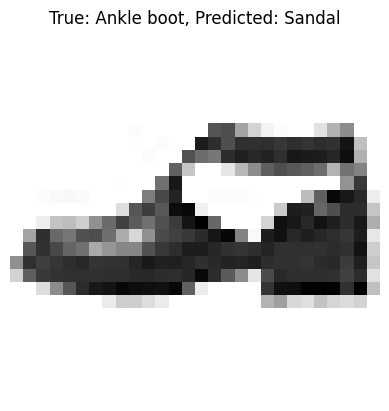

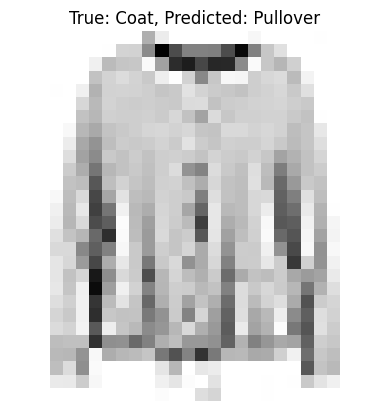

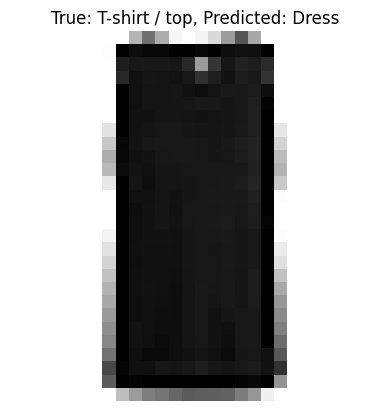

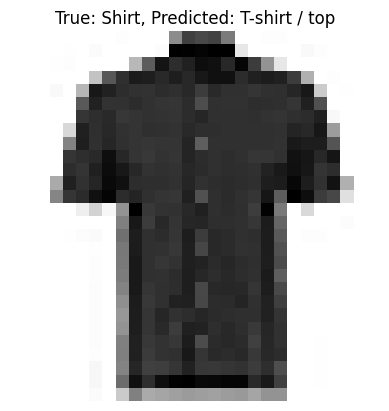

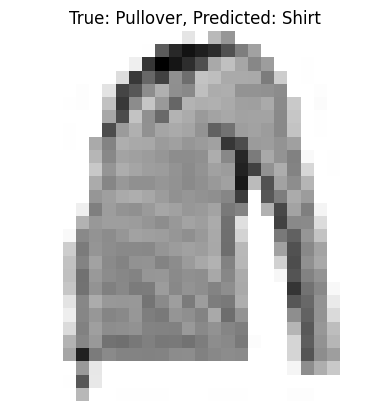

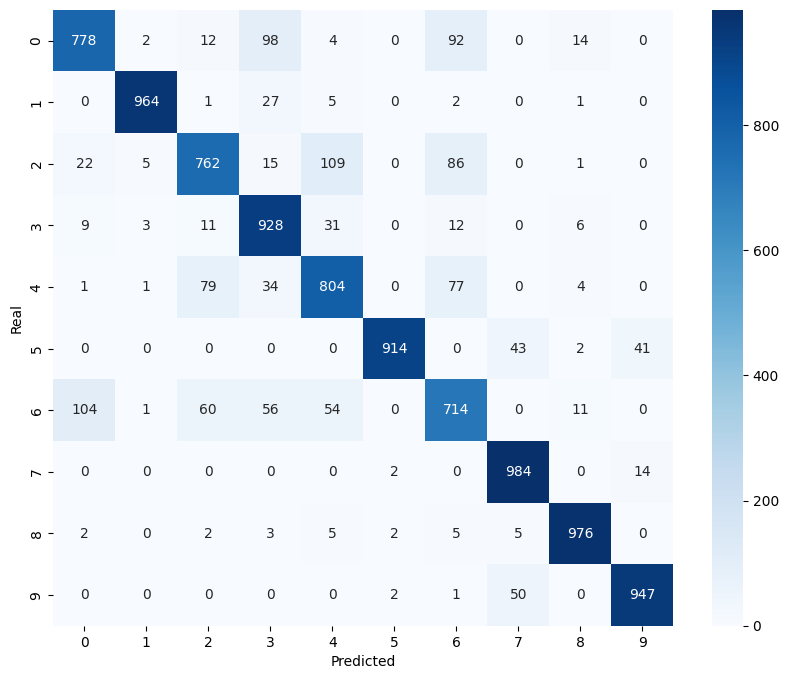

In [6]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

def class_rep(label):
  match label:
    case 0:
      return "T-shirt / top"
    case 1:
      return "Trouser"
    case 2:
      return "Pullover"
    case 3:
      return "Dress"
    case 4:
      return "Coat"
    case 5:
      return "Sandal"
    case 6:
      return "Shirt"
    case 7:
      return "Sneaker"
    case 8:
      return "Bag"
    case 9:
      return "Ankle boot"
    case _:
      return "Different category"
predictions=model.predict(x_test)
predicted_labels=np.argmax(predictions,axis=1)

misclassified_indices=np.where(predicted_labels != y_test)[0]

def plot_prediction(index,is_misclassified=False):
    idx=misclassified_indices[index] if is_misclassified else index
    plt.imshow(x_test[idx],cmap=plt.cm.binary)
    plt.title(f"True: {class_rep(y_test[idx])}, Predicted: {class_rep(predicted_labels[idx])}")
    plt.axis('off')
    plt.show()

print("Examples where model made mistakes:")
for i in range(5):
    plot_prediction(i, is_misclassified=True)

cm=confusion_matrix(y_test,predicted_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Real')
classes=[class_rep(i) for i in range(10)]
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=classes,yticklabels=classes)
plt.show()